In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import find_peaks
from scipy import constants
from lmfit.models import LinearModel
from lmfit import Model

In [229]:
def plot_wavelength(data_path):
    # 1. Carga de datos
    df = pd.read_csv('data/' + data_path)
    d = df['d [cm]']
    dd = df['dd [cm]']
    I = df['I [V]']-1
    dI = df['dI [V]']

    # 2. Detección de picos
    # Ajustamos 'distance' para evitar detectar ruidos como picos
    index, _ = find_peaks(I, height=0.5, distance=5) 
    d_peaks = d.iloc[index].values
    I_peaks = I.iloc[index].values

    # 3. Configuración de la Gráfica
    fig, ax = plt.subplots(figsize= (6, 4), dpi=120)

    # Datos experimentales con barras de error
    ax.errorbar(d, I, xerr=dd, yerr=dI, 
                fmt='s', markersize=1, capsize=2, 
                ecolor='k', color='k', 
                label='Datos Experimentales', elinewidth = 0.8)
    
    # PARÁMETROS DE DECAIMIENTO (Ajuste Manual Sugerido)
    A0 = I_peaks[0]           # Amplitud inicial en el primer pico
    lamda_ref = 2.84          # Tu valor de lambda anterior
    alpha = 0.11              # COEFICIENTE DE DECAIMIENTO (Ajusta este valor si baja muy rápido)
    d0 = d_peaks[0]           # Punto de referencia para el inicio del decaimiento
    
    # Cálculo de la Curva Teórica con Envolvente
    t = np.linspace(d.min(), d.max(), 1000)
    
    # Envolvente exponencial:
    envolvente = A0 * np.exp(-alpha * (t - d0))
    
    # Función oscilatoria alineada con el primer pico:
    frecuencia = 4 * np.pi / lamda_ref
    # Usamos cos^2 para que el máximo coincida con d0 y no baje de cero
    oscilacion = np.cos(frecuencia / 2 * (t - 30.55))**2
    
    y_teorica = envolvente * oscilacion
    ax.plot(t, y_teorica, color='#1E90FF', linewidth=0.8, 
            label='Teoría', zorder=2)

    # Resaltado de Máximos Detectados
    ax.scatter(d_peaks, I_peaks, color='red', s=25, marker='v', 
               label='Máximos Detectados', zorder=5)

    # Anotaciones de los picos (opcional, para mayor claridad)
    for i, txt in enumerate(d_peaks):
        ax.annotate(f'{txt:.2f}', (d_peaks[i], I_peaks[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', 
                    fontsize=7, color='red', fontweight='bold')

    # Estética de Ejes
    ax.set_title(f'Determinación de la Longitud de onda', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Posición ($d$) [cm]', fontsize=12)
    ax.set_ylabel('Intensidad (I) [V]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    ax.set_ylim(-0.15, 2)

    # 4. Guardado y Visualización
    plt.tight_layout()
    plt.savefig('plots/EXP1_wavelength', bbox_inches='tight')
    plt.show()

    # 5. Cálculo de Lambda basado en la diferencia de picos
    if len(d_peaks) > 1:
        diff_d = np.diff(d_peaks)
        dA = 2*np.std(diff_d)
        A = 2*np.mean(diff_d)
        print(f'\u03bb = ({A:.2f} \u00b1 {dA:.2f}) cm')

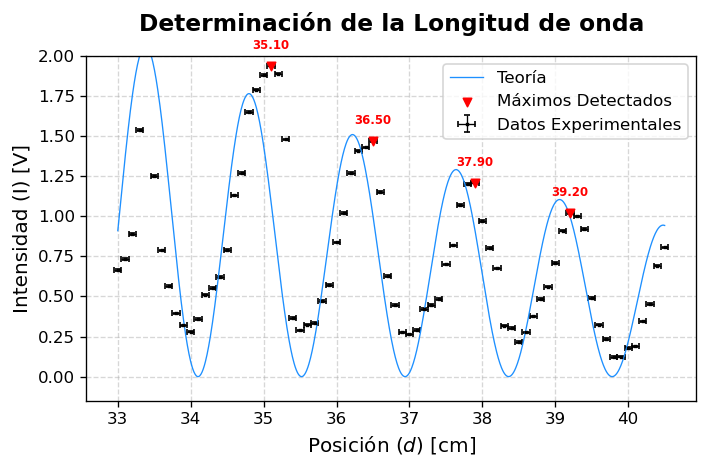

λ = (2.90 ± 0.30) cm


In [230]:
plot_wavelength('EXP_wavelength_14_04_2026.csv')

In [268]:
def plot_miller(data_path, miller = 100, wavelength = 2.85, n = 1, height = 0.005, distance = 5, valid = None, sat = 80): 
    hkl = tuple(map(int, str(miller)))
    
    df = pd.read_csv('data/' + data_path)
    theta = df['theta [deg]']
    dtheta = df['dtheta [deg]']
    I = (df['I [mV]']-np.min(df['I [mV]']))/(np.max(df['I [mV]'])-np.min(df['I [mV]']))
    dI = df['dI [mV]']/(np.max(df['I [mV]'])-np.min(df['I [mV]']))
    
    index, _ = find_peaks(I, height = height, distance= distance)
    theta_peaks = theta.iloc[index].values
    I_peaks = I.iloc[index].values
    
    data_bragg = {'miller': [], 'n': [], 'theta': [], 'I': [], 'd': [], 'a': []}
    
    fig, ax = plt.subplots(figsize= (6, 4), dpi=120)
    ax.errorbar(theta, I, xerr=dtheta, yerr=dI, 
            fmt='s', markersize=1, capsize=2, 
            ecolor='k', color='k', 
            label='Datos Experimentales', elinewidth = 0.8)
    flag = 0
    for i, txt in enumerate(theta_peaks):
        # Lógica de validación
        is_peak_valid = False
        if valid is not None:
            for v_val in valid:
                if np.abs(txt - v_val) < 1.5:
                    is_peak_valid = True
                    break

        if is_peak_valid:
            d_val = (n+flag)*wavelength/(2*np.sin(np.deg2rad(txt)))
            a_val = d_val*np.sqrt(sum(i**2 for i in hkl))
            
            data_bragg['miller'].append(miller)
            data_bragg['n'].append(n+flag)
            data_bragg['theta'].append(txt)
            data_bragg['I'].append(I_peaks[i])
            data_bragg['d'].append(d_val)
            data_bragg['a'].append(a_val)
            flag +=1

            ax.scatter(txt, I_peaks[i], color='red', s=30, marker='v', zorder=5, label='Máximos de Bragg')
            ax.annotate(f'{txt:.2f}', (txt, I_peaks[i]), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=7, color='red', fontweight='bold')
        else:

            ax.scatter(txt, I_peaks[i], color='gray', s=30, marker='x', zorder=4, label='Máximos por Artefactos')
            ax.annotate(f'{txt:.2f}', (txt, I_peaks[i]), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=7, color='gray', fontweight='bold', alpha=0.7)

    ax.axvspan(sat, 90.5, color='red', alpha=0.1, zorder=0, label='Zona de Saturación')

    ax.set_title(f'Difracción de Bragg en el Plano de Miller ({miller})', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Ángulo ($\\theta$ )[deg]', fontsize=12)
    ax.set_ylabel('Intensidad Relativa (I) [arbs]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'plots/EXP2_miller_{miller}', bbox_inches='tight')
    plt.show()

    return pd.DataFrame(data_bragg)

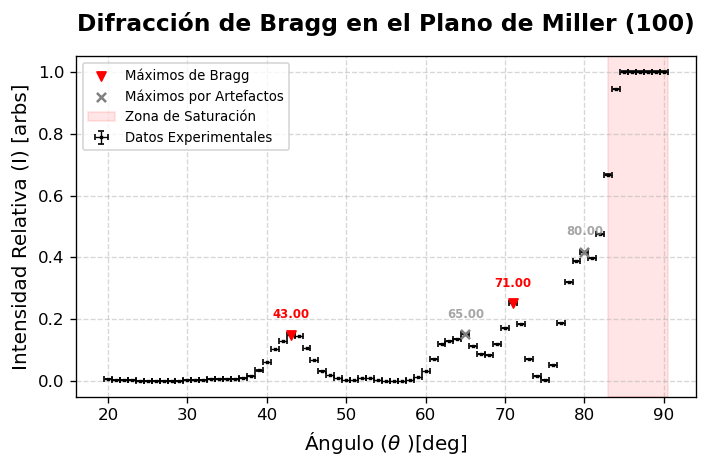

,miller,n,theta,I,d,a
0,100,2,43,0.149762,4.178896,4.178896
1,100,3,71,0.251885,4.521328,4.521328


In [274]:
bragg = plot_miller('EXP_miller_100_16_04_2026.csv', miller  = 100, n=2, height = 0.1, distance = 5, valid = [43, 71], sat = 83)
bragg

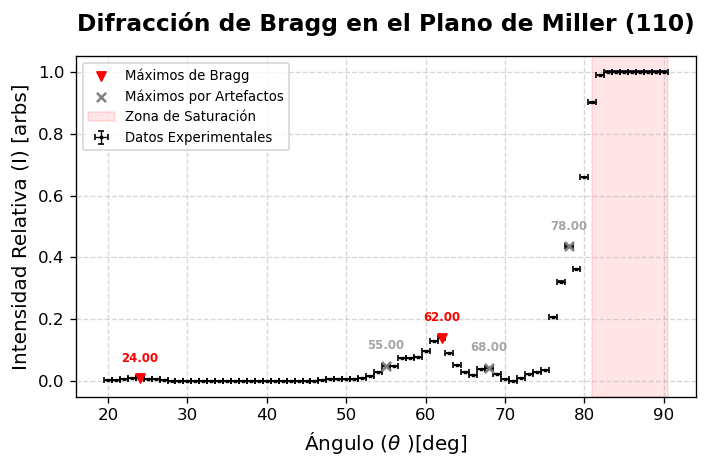

,miller,n,theta,I,d,a
0,110,1,24,0.009360,3.503496,4.954691
1,110,2,62,0.140019,3.227825,4.564833


In [273]:
bragg = plot_miller('EXP_miller_110_16_04_2026.csv',miller = 110, n=1, height = 0.009, distance = 5, valid = [24, 62], sat = 81)
bragg

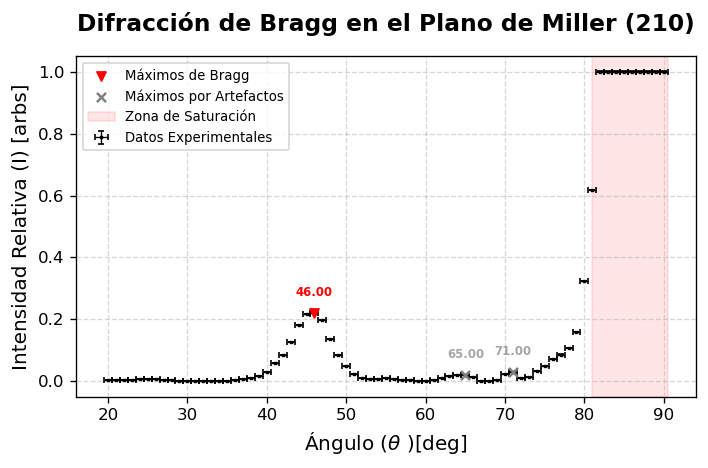

,miller,n,theta,I,d,a
0,210,1,46,0.220046,1.980983,4.429613


In [270]:
plot_miller('EXP_miller_210_16_04_2026.csv',210, n= 1, height = 0.009, distance = 5, valid = [46], sat = 81)

In [266]:
a_list = [4.178896, 4.521328, 4.954691, 4.564833, 4.429613]
a = np.mean(a_list)
da = np.std(a_list)
print(f'Parámetro de Red: a = ({a:.2f} \u00b1 {da:.2f})cm ')

Parámetro de Red: a = (4.53 ± 0.25)cm 
